In [37]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from tqdm import tqdm
from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline


In [38]:
INPUT = 'data/news_vnexpress/'
os.makedirs("images",exist_ok=True) # thư mục lưu các hình ảnh kết quả trong quá trình huấn luyện và đánh giá

In [39]:
# statistics
print('Các nhãn và số văn bản tương ứng trong dữ liệu')
print('----------------------------------------------')
n = 0
for label in os.listdir(INPUT):
    print(f'{label}: {len(os.listdir(os.path.join(INPUT, label)))}')
    n += len(os.listdir(os.path.join(INPUT, label)))
print('-------------------------')
print(f"Tổng số văn bản: {n}")


Các nhãn và số văn bản tương ứng trong dữ liệu
----------------------------------------------
doi-song: 120
du-lich: 54
giai-tri: 201
giao-duc: 105
khoa-hoc: 144
kinh-doanh: 262
phap-luat: 59
suc-khoe: 162
the-thao: 173
thoi-su: 59
-------------------------
Tổng số văn bản: 1339


In [40]:
# load data
data_train = load_files(container_path=INPUT, encoding="utf-8")
print('mapping:')

for i in range(len(data_train.target_names)):
    print(f'{data_train.target_names[i]} - {i}')

print('--------------------------')
print(data_train.filenames[0:1])
# print(data_train.data[0:1])
print(data_train.target[0:1])
print(data_train.data[0:1])
print("\nTổng số văn bản: {}" .format( len(data_train.filenames)))


mapping:
doi-song - 0
du-lich - 1
giai-tri - 2
giao-duc - 3
khoa-hoc - 4
kinh-doanh - 5
phap-luat - 6
suc-khoe - 7
the-thao - 8
thoi-su - 9
--------------------------
['data/news_vnexpress/khoa-hoc\\00133.txt']
[4]
['Mời độc giả đặt câu hỏi tại đây\n']

Tổng số văn bản: 1339


In [41]:
with open('data/vietnamese-stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = f.readlines()

stopwords = [word.strip().replace(' ',',') for word in stopwords]
print(stopwords[0:10])
print('Tổng số stopwords: {}'.format(len(stopwords)))

module_count_vector = CountVectorizer(stop_words=stopwords)
model_rf_preprocess = Pipeline([('count_vectorizer', module_count_vector),("tfidf", TfidfTransformer())])

data_preprocessed = model_rf_preprocess.fit_transform(data_train.data)

print('Kích thước ma trận đặc trưng: {}'.format(data_preprocessed.shape))


['a,lô', 'a,ha', 'ai', 'ai,ai', 'ai,nấy', 'ai,đó', 'alô', 'amen', 'anh', 'anh,ấy']
Tổng số stopwords: 2063


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['bao', 'bay', 'biến', 'biệt', 'bây', 'bõm', 'bảo', 'bất', 'bẩy', 'bập', 'bắt', 'bội', 'chao', 'chi', 'chia', 'chu', 'chui', 'chuẩn', 'chà', 'chành', 'chí', 'chót', 'chùn', 'chăn', 'chũn', 'chưng', 'chạnh', 'chả', 'chầm', 'chầy', 'chập', 'chắn', 'chẳng', 'chết', 'chốc', 'chừ', 'chừng', 'coi', 'cu', 'cá', 'câu', 'cóc', 'công', 'cạnh', 'cảm', 'cầu', 'cật', 'cắt', 'cổ', 'cụ', 'cục', 'cực', 'da', 'dà', 'dĩ', 'dưng', 'dần', 'dầu', 'dịp', 'dở', 'dụng', 'gian', 'giá', 'giác', 'giời', 'ha', 'hiện', 'hoàn', 'hèn', 'hình', 'hô', 'hầu', 'hậu', 'hẳn', 'hồ', 'hỗ', 'hội', 'hợp', 'hự', 'khói', 'khô', 'khăn', 'khắc', 'khẳng', 'kia', 'kiện', 'kê', 'kì', 'kìa', 'kỳ', 'lai', 'le', 'liên', 'liệt', 'loạt', 'luận', 'luật', 'luốt', 'lình', 'lí', 'lô', 'lý', 'lập', 'lẽ', 'lị', 'lự', 

Kích thước ma trận đặc trưng: (1339, 12796)


In [42]:
p = 0.2
pivot = int(len(data_train.data) * (1-p))
X_train, X_test = data_preprocessed[:pivot], data_preprocessed[pivot:]
y_train, y_test = data_train.target[:pivot], data_train.target[pivot:]



In [43]:
def cross_validation(estimator):
    _, train_scores, test_scores = learning_curve(estimator, X_train, y_train,cv=10, n_jobs=-1, train_sizes=[1.0, ], scoring="accuracy")
    test_scores = test_scores[0]
    mean, std = test_scores.mean(), test_scores.std()
    return mean, std

def plot(title, xlabel, X, Y, error, ylabel = "Accuracy"):
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid()
    plt.ylabel(ylabel)
    plt.errorbar(X, Y, error, linestyle='None', marker='o')


100%|██████████| 4/4 [00:25<00:00,  6.44s/it]


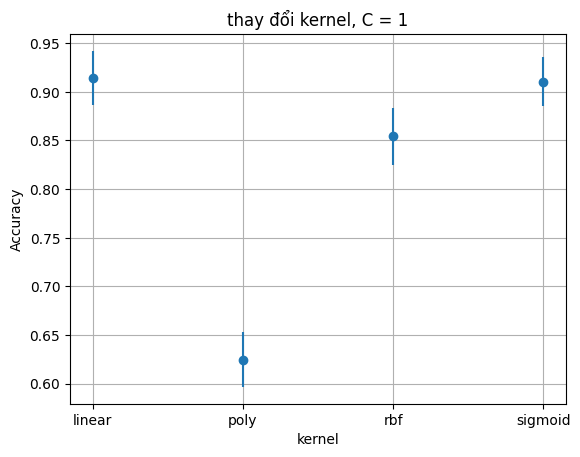

In [44]:
title = "thay đổi kernel, C = 1"
xlabel = "kernel"
X = []
Y = []
error = []
for kernel in tqdm(['linear', 'poly', 'rbf', 'sigmoid']):
    # Với mỗi kernel được chọn,
    # thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel=kernel, C=1.0)
    mean, std = cross_validation(text_clf)
    X.append(kernel)
    Y.append(mean)
    error.append(std)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y, error)
plt.savefig('images/svm_change_kernel.png', bbox_inches='tight')
plt.show()


100%|██████████| 5/5 [00:23<00:00,  4.63s/it]


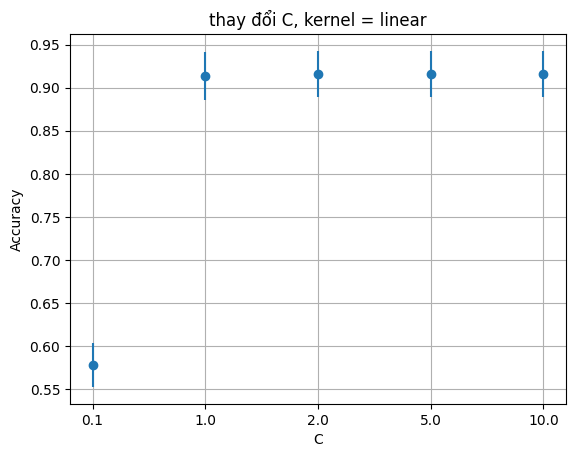

In [45]:
title = "thay đổi C, kernel = linear"
xlabel = "C"
X = []
Y = []
error = []
for C in tqdm([.1, 1.0, 2.0, 5.0, 10.0]):
    # Với từng giá trị C nhận được,
    # thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel='linear', C=C)
    mean, std = cross_validation(text_clf)
    X.append(str(C))
    Y.append(mean)
    error.append(std)
    # lưu kết quả ra file ảnh
plot(title, xlabel, X, Y, error)
plt.savefig('images/svm_change_C.png', bbox_inches='tight')
plt.show()

100%|██████████| 2/2 [00:03<00:00,  1.69s/it]


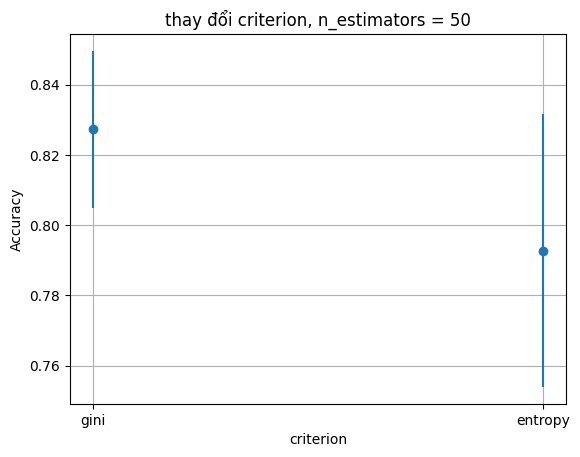

In [46]:
title = "thay đổi criterion, n_estimators = 50"
xlabel = "criterion"
X = []
Y = []
error = []
for criterion in tqdm(["gini", "entropy"]):
    # Với mỗi criterion nhận được,
    # thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = RandomForestClassifier(criterion=criterion, n_estimators=50)
    mean, std = cross_validation(text_clf)
    X.append(str(criterion))
    Y.append(mean)
    error.append(std)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y, error)
plt.savefig('images/RF_change_criterion.png', bbox_inches='tight')
plt.show()

100%|██████████| 4/4 [00:12<00:00,  3.18s/it]


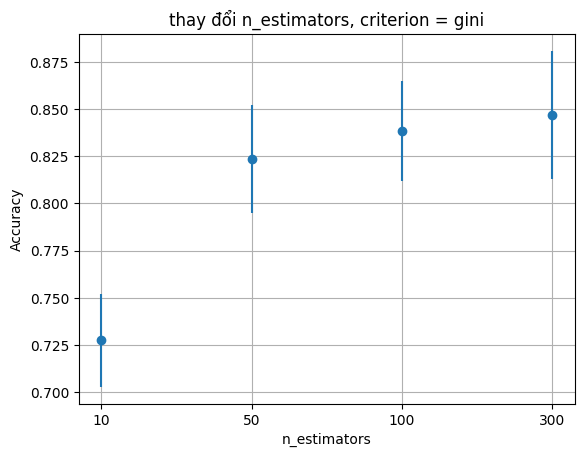

In [47]:
title = "thay đổi n_estimators, criterion = gini"
xlabel = "n_estimators"
X = []
Y = []
error = []
for n_estimators in tqdm([10, 50, 100, 300]):
    # Với từng giá trị n_estimators nhận được,
    # thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = RandomForestClassifier(criterion='gini', n_estimators=n_estimators)
    mean, std = cross_validation(text_clf)
    X.append(str(n_estimators))
    Y.append(mean)
    error.append(std)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y, error)
plt.savefig('images/RF_change_N.png', bbox_inches='tight')
plt.show()


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:04<00:00,  1.02it/s]


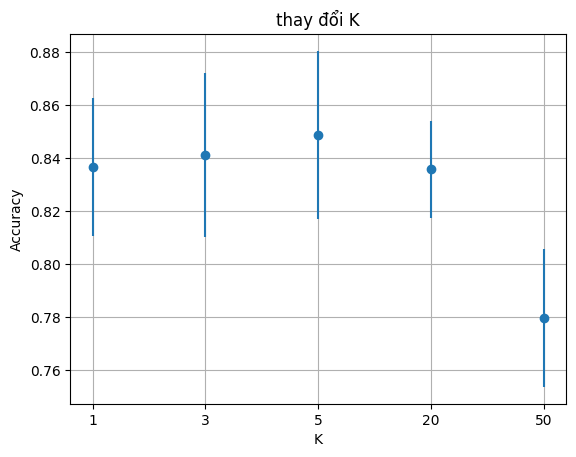

In [48]:
from sklearn.neighbors import KNeighborsClassifier
title = "thay đổi K"
xlabel = "K"
X = []
Y = []
error = []
for k in tqdm([1, 3, 5, 20, 50]):
    # Với từng giá trị k nhận được,
    # thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = KNeighborsClassifier(n_neighbors=k)
    mean, std = cross_validation(text_clf)
    X.append(str(k))
    Y.append(mean)
    error.append(std)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y, error)
plt.savefig('images/KNN_change_K.png', bbox_inches='tight')
plt.show()


In [49]:
svm_ = svm.SVC(kernel='linear', C=1.0)
rf = RandomForestClassifier(criterion='gini', n_estimators=300)
knn = KNeighborsClassifier(n_neighbors=5)
# Huấn luyện các mô hình trên tập dữ liệu train đầy đủ
svm_.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
# Kết quả dự đoán trên tập test
print(f'SVM: {accuracy_score(y_test, svm_.predict(X_test))}')
print(f'RF: {accuracy_score(y_test, rf.predict(X_test))}')
print(f'KNN: {accuracy_score(y_test, knn.predict(X_test))}')


SVM: 0.9253731343283582
RF: 0.8395522388059702
KNN: 0.8395522388059702


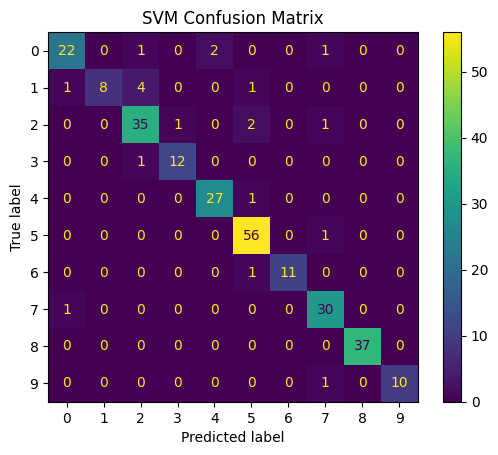

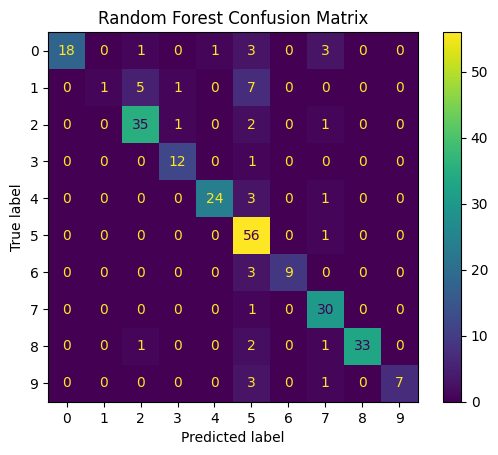

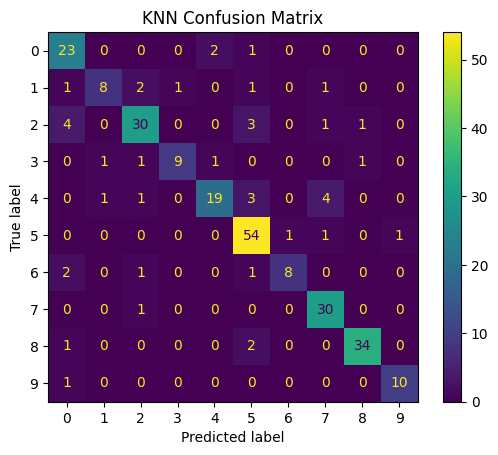

In [51]:
ConfusionMatrixDisplay.from_estimator(svm_, X_test, y_test)
plt.title('SVM Confusion Matrix')
plt.show()

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title('Random Forest Confusion Matrix')
plt.show()

ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.title('KNN Confusion Matrix')
plt.show()
